In [2]:
%matplotlib inline
%config InlineBackend.figure_format = 'retina'
import sys, platform, os
sys.path.append('/project/chihway/junzhou/cocoa_approx/Cocoa/projects/roman_real/interface/')
os.environ['OMP_NUM_THREADS'] = '8'
import matplotlib
import math
from matplotlib import pyplot as plt
import numpy as np
import scipy
import cosmolike_roman_real_interface as ci
from getdist import IniFile
from scipy.interpolate import interp1d
import itertools
import iminuit
import functools
print(sys.version)
print(os.getcwd())

# GENERAL PLOT OPTIONS
matplotlib.rcParams['mathtext.fontset'] = 'stix'
matplotlib.rcParams['font.family'] = 'STIXGeneral'
matplotlib.rcParams['mathtext.rm'] = 'Bitstream Vera Sans'
matplotlib.rcParams['mathtext.it'] = 'Bitstream Vera Sans:italic'
matplotlib.rcParams['mathtext.bf'] = 'Bitstream Vera Sans:bold'
matplotlib.rcParams['xtick.bottom'] = True
matplotlib.rcParams['xtick.top'] = False
matplotlib.rcParams['ytick.right'] = False
matplotlib.rcParams['axes.edgecolor'] = 'black'
matplotlib.rcParams['axes.linewidth'] = '1.0'
matplotlib.rcParams['axes.labelsize'] = 'medium'
matplotlib.rcParams['axes.grid'] = True
matplotlib.rcParams['grid.linewidth'] = '0.0'
matplotlib.rcParams['grid.alpha'] = '0.18'
matplotlib.rcParams['grid.color'] = 'lightgray'
matplotlib.rcParams['legend.labelspacing'] = 0.77
matplotlib.rcParams['savefig.bbox'] = 'tight'
matplotlib.rcParams['savefig.format'] = 'pdf'
# ----------------------------------------------------------------------------------------------------------------------------------
# ----------------------------------------------------------------------------------------------------------------------------------
# ----------------------------------------------------------------------------------------------------------------------------------
# BE CAREFUL: you need texlive-latex-base texlive-latex-extra texlive-fonts-recommended dvipng ghostscript cm-super
matplotlib.rcParams['text.usetex'] = False
# ----------------------------------------------------------------------------------------------------------------------------------
# ----------------------------------------------------------------------------------------------------------------------------------
# ----------------------------------------------------------------------------------------------------------------------------------

# Jupyter Notebook Display options
import IPython
IPython.display.display(IPython.display.HTML("<style>:root { --jp-notebook-max-width: 85% !important; }</style>"))
IPython.display.display(IPython.display.HTML("<style>div.output_scroll { height: 54em; }</style>"))

# IMPORT CAMB
sys.path.insert(0, '/project/chihway/junzhou/cocoa_approx/Cocoa/external_modules/code/CAMB/build/lib.linux-x86_64-cpython-310')
if "camb" in sys.modules:
    del sys.modules["camb"]
import camb
from camb import model
print('Using CAMB %s installed at %s'%(camb.__version__,os.path.dirname(camb.__file__)))

# IMPORT EuclideEmulator2
sys.path.insert(0, '/project/chihway/junzhou/cocoa_approx/Cocoa/external_modules/code/euclidemu2/build/lib.linux-x86_64-cpython-310')
if "euclidemu2" in sys.modules:
    del sys.modules["euclidemu2"]
import euclidemu2
#print('Using eucl %s installed at %s'%(camb.__version__,os.path.dirname(camb.__file__)))


CAMBAccuracyBoost = 1.0
non_linear_emul = 1
CLprobe="3x2pt"

path= "./data/"
data_file="roman_ones.dataset"

IA_model = 0
IA_redshift_evolution = 3

ntheta = 20
theta_min_arcmin = 1.0 
theta_max_arcmin = 500.0

As_1e9= 2.1
ns= 0.96605
H0= 67.32
omegab= 0.0495
omegam= 0.316
mnu= 0.06

roman_DZ_S1= 0.0
roman_DZ_S2= 0.0
roman_DZ_S3= 0.0
roman_DZ_S4= 0.0
roman_DZ_S5= 0.0
roman_DZ_S6= 0.0
roman_DZ_S7= 0.0
roman_DZ_S8= 0.0

roman_DZ_L1= 0.0
roman_DZ_L2= 0.0
roman_DZ_L3= 0.0
roman_DZ_L4= 0.0
roman_DZ_L5= 0.0
roman_DZ_L6= 0.0
roman_DZ_L7= 0.0
roman_DZ_L8= 0.0

roman_M1= 0.0
roman_M2= 0.0
roman_M3= 0.0
roman_M4= 0.0
roman_M5= 0.0
roman_M6= 0.0
roman_M7= 0.0
roman_M8= 0.0

roman_A1_1= 0.5
roman_A1_2= 0.0

roman_B1_1= 1.24
roman_B1_2= 1.40
roman_B1_3= 1.54
roman_B1_4= 1.69
roman_B1_5= 1.86
roman_B1_6= 2.08
roman_B1_7= 2.40
roman_B1_8= 3.02

w0pwa= -1.0
w= -1.0

def get_camb_cosmology(omegam = omegam, omegab = omegab, H0 = H0, ns = ns, 
                    As_1e9 = As_1e9, w = w, w0pwa = w0pwa, AccuracyBoost=1.0, 
                    kmax=5.0, k_per_logint=10, CAMBAccuracyBoost=1.0,
                    non_linear_emul=non_linear_emul):

    As = lambda As_1e9: 1e-9 * As_1e9
    wa = lambda w0pwa, w: w0pwa - w
    omegabh2 = lambda omegab, H0: omegab*(H0/100)**2
    omegach2 = lambda omegam, omegab, mnu, H0: (omegam-omegab)*(H0/100)**2-(mnu*(3.046/3)**0.75)/94.0708
    omegamh2 = lambda omegam, H0: omegam*(H0/100)**2

    CAMBAccuracyBoost = CAMBAccuracyBoost*AccuracyBoost
    kmax = kmax*(1.0 + 3*(CAMBAccuracyBoost-1))
    k_per_logint = int(k_per_logint) + int(3*(CAMBAccuracyBoost-1))
    extrap_kmax=2.5e2*CAMBAccuracyBoost
    tmp=1250
    z_interp_1D = np.concatenate((np.linspace(0.0,3.0,max(100,int(0.80*tmp))),
                                np.linspace(3.0,50.1,max(100,int(0.40*tmp)))),axis=0)
    len_z_interp_1D = len(z_interp_1D)
    tmp=140
    z_interp_2D = np.concatenate((np.linspace(0,3.0,max(50,int(0.75*tmp))), 
                                np.linspace(3.01,50.1,max(30,int(0.25*tmp)))),axis=0)
    len_z_interp_2D = len(z_interp_2D)
    tmp=1500
    log10k_interp_2D = np.linspace(-4.99,2.0,tmp)
    len_log10k_interp_2D = len(log10k_interp_2D)

    pars = camb.set_params(H0=H0, 
                        ombh2=omegabh2(omegab, H0), 
                        omch2=omegach2(omegam, omegab, mnu, H0), 
                        mnu=mnu, 
                        omk=0, 
                        tau=0.06,  
                        As=As(As_1e9), 
                        ns=ns, 
                        halofit_version='mead2020', 
                        lmax=10,
                        AccuracyBoost=CAMBAccuracyBoost,
                        lens_potential_accuracy=1.0,
                        num_massive_neutrinos=1,
                        nnu=3.046,
                        accurate_massive_neutrino_transfers=False,
                        k_per_logint=k_per_logint,
                        kmax = kmax);
    pars.set_dark_energy(w=w, wa=wa(w0pwa, w), dark_energy_model='ppf');    
    pars.NonLinear = model.NonLinear_both
    pars.set_matter_power(redshifts = z_interp_2D, kmax = kmax, silent = True);
    results = camb.get_results(pars)
    PKL  = results.get_matter_power_interpolator(var1="delta_tot", var2="delta_tot", nonlinear = False, 
                                                extrap_kmax = extrap_kmax, hubble_units = False, k_hunit = False);
    PKNL = results.get_matter_power_interpolator(var1="delta_tot", var2="delta_tot",  nonlinear = True, 
                                                extrap_kmax = extrap_kmax, hubble_units = False, k_hunit = False);
    lnPL = np.log(PKL.P(z_interp_2D,np.power(10.0,log10k_interp_2D)).flatten(order='F'))+np.log((H0/100.0)**3) 
    if non_linear_emul == 1:
        params = { 'Omm'  : omegam, 
                'As'   : As(As_1e9), 
                'Omb'  : omegab,
                'ns'   : ns, 
                'h'    : H0/100., 
                'mnu'  : mnu,  
                'w'    : w, 
                'wa'   : wa(w0pwa, w)
                }
        kbt, tmp_bt = euclidemu2.get_boost(params,z_interp_2D[z_interp_2D < 10.0],10**np.linspace(-2.0589,0.973,len_log10k_interp_2D))
        bt = np.array(tmp_bt, dtype='float64')  
        tmp = interp1d(np.log10(kbt), 
                        np.log(bt), 
                        axis=1,
                        kind='linear', 
                        fill_value='extrapolate', 
                        assume_sorted=True)(log10k_interp_2D-np.log10(H0/100.)) #h/Mpc
        tmp[:,10**(log10k_interp_2D-np.log10(H0/100)) < 8.73e-3] = 0.0
        lnbt = np.zeros((len_z_interp_2D, len_log10k_interp_2D))
        lnbt[z_interp_2D < 10.0, :] = tmp
        # Use Halofit first that works on all redshifts
        lnPNL = np.log(PKNL.P(z_interp_2D,np.power(10.0,log10k_interp_2D)).flatten(order='F'))+np.log((H0/100.0)**3) 
        # on z < 10.0, replace it with EE2
        lnPNL = np.where((z_interp_2D<10)[:,None], lnPL.reshape(len_z_interp_2D,len_log10k_interp_2D,order='F')+lnbt, 
                                                lnPNL.reshape(len_z_interp_2D,len_log10k_interp_2D,order='F')).ravel(order='F')
    elif non_linear_emul == 2:
        lnPNL = np.log(PKNL.P(z_interp_2D,np.power(10.0,log10k_interp_2D)).flatten(order='F'))+np.log((H0/100.0)**3)  
    log10k_interp_2D = log10k_interp_2D - np.log10(H0/100.)
    G_growth = np.sqrt(PKL.P(z_interp_2D,0.0005)/PKL.P(0,0.0005))*(1 + z_interp_2D)
    G_growth = G_growth/G_growth[len(G_growth)-1]
    chi = results.comoving_radial_distance(z_interp_1D) * (H0/100.)
    return (log10k_interp_2D, z_interp_2D, lnPL, lnPNL, G_growth, z_interp_1D, chi)

def get_growth_parameters(
                    omegam = omegam, 
                    omegab = omegab, 
                    H0 = H0, 
                    ns = ns, 
                    As_1e9 = As_1e9, 
                    w = w, 
                    w0pwa = w0pwa,
                    AccuracyBoost = 1.0, 
                    kmax = 5.0, 
                    k_per_logint = 10, 
                    CAMBAccuracyBoost=1.0,
                    CLAccuracyBoost = 1.0, 
                    CLIntegrationAccuracy=0,
                    non_linear_emul=non_linear_emul):

    (log10k_interp_2D, z_interp_2D, lnPL, lnPNL, G_growth, z_interp_1D, chi) = get_camb_cosmology(omegam=omegam, 
                                                                                                omegab=omegab, 
                                                                                                H0=H0, 
                                                                                                ns=ns, 
                                                                                                As_1e9=As_1e9, 
                                                                                                w=w, 
                                                                                                w0pwa=w0pwa,
                                                                                                AccuracyBoost=AccuracyBoost,
                                                                                                kmax=kmax,
                                                                                                k_per_logint=k_per_logint,
                                                                                                CAMBAccuracyBoost=CAMBAccuracyBoost,
                                                                                                non_linear_emul=non_linear_emul)
    return z_interp_1D, chi, z_interp_2D, G_growth

# Init Cosmolike
adopt_limber_gg = 1
adopt_limber_gs = 1
adopt_RSD_gg = 1
adopt_RSD_gs = 1
NCell_interpolation = 1000
Na_interpolation = 1000

# Init Cosmolike
ini = IniFile(os.path.normpath(os.path.join(path, data_file)))
lens_file = ini.relativeFileName('nz_lens_file')
source_file = ini.relativeFileName('nz_source_file')
lens_ntomo = ini.int("lens_ntomo")
source_ntomo = ini.int("source_ntomo")
ci.initial_setup(
      adopt_limber_gg,
    adopt_limber_gs,
    adopt_RSD_gg,
    adopt_RSD_gs,
    NCell_interpolation,
    Na_interpolation,)
ci.init_accuracy_boost(1.0, int(1))
ci.init_cosmo_runmode(is_linear = False)
ci.init_redshift_distributions_from_files(
      lens_multihisto_file=lens_file,
      lens_ntomo=int(lens_ntomo), 
      source_multihisto_file=source_file,
      source_ntomo=int(source_ntomo))
ci.init_IA(ia_model = int(IA_model), ia_redshift_evolution = int(IA_redshift_evolution))

z, chiofz, z_G, G_growth = get_growth_parameters()

3.10.17 | packaged by conda-forge | (main, Apr 10 2025, 22:19:12) [GCC 13.3.0]
/project/chihway/junzhou/cocoa_approx/Cocoa/projects/roman_real


Using CAMB 1.5.9 installed at /project/chihway/junzhou/cocoa_approx/Cocoa/external_modules/code/CAMB/build/lib.linux-x86_64-cpython-310/camb

Classy could not be found in your system.
Here are some suggestions:

	 -Download the Class from class-code.net and install it
	  together with its wrapper classy (type 'make' instead of
	  'make class'
	 -If you know that Class is installed on your system
	  and yet classy could not be installed, try re-compiling
	  Class with just ''make'' instead of ''make class''
NOTICE: Even without classy you can still use EuclidEmulator2
        to emulate boost factors. You won't be able to compute
        full power spectra, though.
/project/chihway/junzhou/cocoa_approx/Cocoa/.local/lib/python3.10/site-packages/euclidemu2/ee2_bindata.dat


### roman paper gives:

$\ell_{min} = 20/30, \ell_{max} = 8000/15000$, $25 \ell$ bins

$area = 5000 \mathrm{deg}^2$

$10$ lens $10$ sources and source=lens

number of effective sample $n_{eff} = 51.03$

### lsst rsd gives:

$\ell_{min} = 20$, \ell_{max} = 15000, $20 \ell$ bins

$Y10 area = 14300 \mathrm{deg}^2$

$10$ lens $10$ sources and source=lens

number of effective sample $n_{eff} = 27.10$

### calcultae chi2

at z = 0.31202762436032966,Rmin = 21Mpc/h gives thetamin = 83.57880632995251 arcmin
at z = 0.5448005418607127,Rmin = 21Mpc/h gives thetamin = 51.02464612711335 arcmin
at z = 0.7425813884471182,Rmin = 21Mpc/h gives thetamin = 39.54742528969863 arcmin
at z = 0.9471314937271436,Rmin = 21Mpc/h gives thetamin = 32.79818032255203 arcmin
at z = 1.176193251317182,Rmin = 21Mpc/h gives thetamin = 28.08005537880367 arcmin
at z = 1.4561141079666104,Rmin = 21Mpc/h gives thetamin = 24.370864802371027 arcmin
at z = 1.857761506252313,Rmin = 21Mpc/h gives thetamin = 21.037320713328615 arcmin
at z = 2.628320137777742,Rmin = 21Mpc/h gives thetamin = 17.52759113238824 arcmin


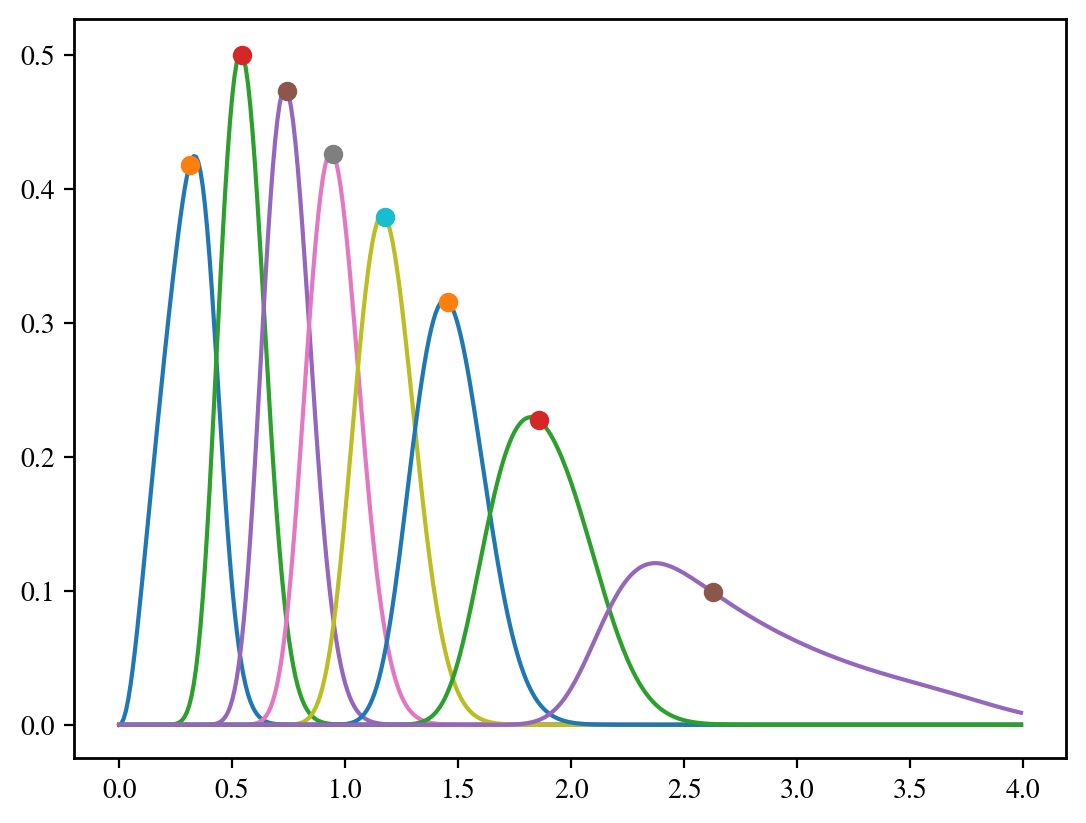

In [3]:

import numpy as np
import matplotlib.pyplot as plt
import camb
import scipy as sp
from scipy.interpolate import interp1d

z,idx = np.unique(z, return_index=True)
chiofz = np.array(chiofz)[idx]
chi = interp1d(z, chiofz, kind='cubic',fill_value='extrapolate')

nz = np.loadtxt('/project/chihway/junzhou/cocoa_approx/Cocoa/projects/roman_real/data/fiducial.nz')

x_medians = []

for i in range(1,nz.shape[1]):
    x = nz[:,0]
    y = nz[:,i]
    Ns = np.concatenate([[0],sp.integrate.cumulative_trapezoid(y,x)])
    x_median = np.interp(Ns[-1]/2, Ns, x)
    y_median = np.interp(x_median, x, y)
    x_medians.append(x_median)
    plt.plot(x,y)
    plt.plot(x_median, y_median, 'o')
    
x_medians = np.array(x_medians)

kmax = 0.3 #h/Mpc
Rmin = 2*np.pi/kmax #Mpc/h
Rmin = 21
#Rmin = 8

thetamins = []
for zi in list(x_medians):
    chi_ = chi(zi)
    # scalecut 2
    thetamin = Rmin/chi_*180/np.pi*60
    thetamins.append(thetamin)
    print(f'at z = {zi},Rmin = {Rmin}Mpc/h gives thetamin =', thetamin,'arcmin')

In [4]:
thetamins

[83.57880632995251,
 51.02464612711335,
 39.54742528969863,
 32.79818032255203,
 28.08005537880367,
 24.370864802371027,
 21.037320713328615,
 17.52759113238824]

### calculate G_growth